# Phase 0: Exploratory Data Analysis (EDA)

Before building our data loaders or training the model, it is crucial to analyze our dataset characteristics. In this notebook, I will explore:
1. Class distribution (checking for data imbalance).
2. Image dimension distributions (to determine the best image resizing target).
3. Average color channel distributions across categories.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

# Define paths
data_dir = "../data/"
categories = ["with_mask", "without_mask"]

# Gather metadata about every image
image_data = []

for category in categories:
    folder_path = os.path.join(data_dir, category)
    if not os.path.exists(folder_path):
        continue
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                # Convert to numpy array to compute mean color channels
                img_array = np.array(img.convert('RGB'))
                r_mean = img_array[:, :, 0].mean()
                g_mean = img_array[:, :, 1].mean()
                b_mean = img_array[:, :, 2].mean()
                
                image_data.append({
                    "filename": img_name,
                    "category": category,
                    "width": width,
                    "height": height,
                    "r_mean": r_mean,
                    "g_mean": g_mean,
                    "b_mean": b_mean
                })
        except Exception as e:
            # Skip corrupted or non-image files if any
            continue

df = pd.DataFrame(image_data)
print(f"Dataset summary compiled! Total images found: {len(df)}")
df.head()

f:\SLIIT\_Year_03_\Semester 01\_ Self Study _\Face-Mask-Detector\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Dataset summary compiled! Total images found: 7553


,filename,category,width,height,r_mean,g_mean,b_mean
0,with_mask_1.jpg,with_mask,525,350,67.081459,66.709540,54.485932
1,with_mask_10.jpg,with_mask,135,218,131.446415,94.394088,58.128508
2,with_mask_100.jpg,with_mask,86,105,104.030454,77.556589,59.500664
3,with_mask_1000.jpg,with_mask,310,403,105.424093,101.465997,91.817186
4,with_mask_1001.jpg,with_mask,121,204,139.196808,113.813563,106.766124


## 1. Class Distribution Analysis

Let's check if our dataset is balanced or heavily skewed toward one class. Severely imbalanced datasets can bias the model's predictions.

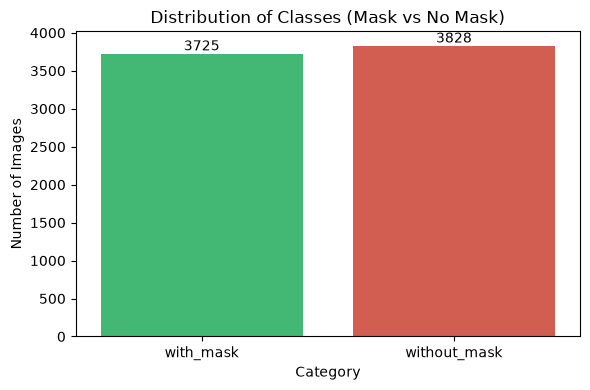

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='category', hue='category', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribution of Classes (Mask vs No Mask)')
plt.xlabel('Category')
plt.ylabel('Number of Images')

# Add value labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 2. Image Dimensions Analysis

Images in raw datasets often come in various shapes and aspect ratios. Analyzing heights and widths helps justify why we resize our inputs to $224 \times 224$ pixels for MobileNetV2.

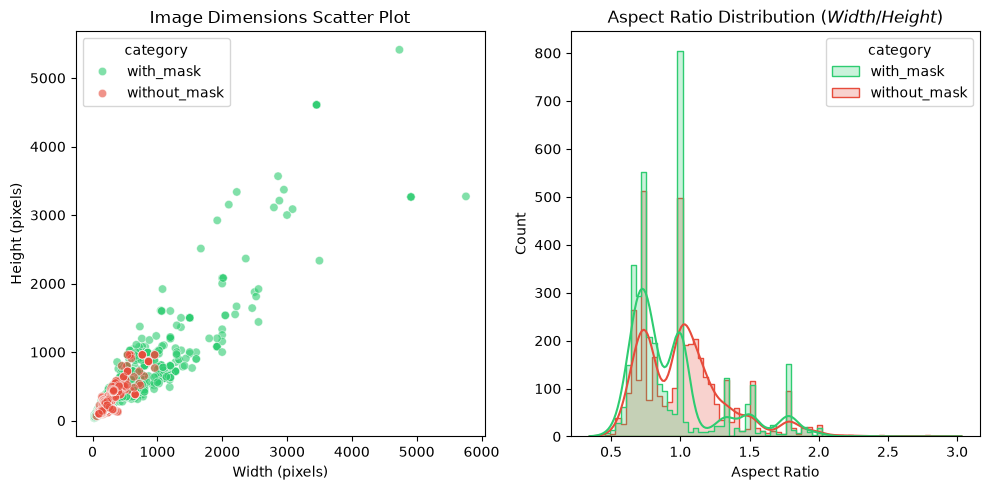

In [4]:
plt.figure(figsize=(10, 5))

# Scatter plot of Width vs Height
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='width', y='height', hue='category', alpha=0.6, palette=['#2ecc71', '#e74c3c'])
plt.title('Image Dimensions Scatter Plot')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')

# Distribution of Aspect Ratios
plt.subplot(1, 2, 2)
df['aspect_ratio'] = df['width'] / df['height']
sns.histplot(data=df, x='aspect_ratio', hue='category', kde=True, element='step', palette=['#2ecc71', '#e74c3c'])
plt.title('Aspect Ratio Distribution ($Width / Height$)')
plt.xlabel('Aspect Ratio')

plt.tight_layout()
plt.show()

## 3. Color Channel Intensity Profiling

Let's see if there is a distinct difference in the average color palettes between people wearing masks and those who aren't. Surgical masks often introduce a lot of bright blue/white hues.

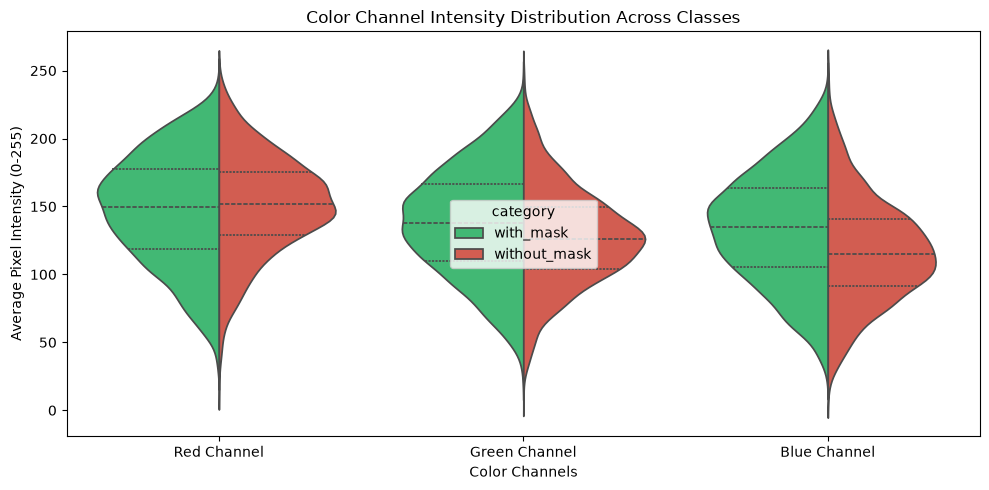

In [5]:
# Melt the dataframe to make it suitable for a violin plot comparison
color_df = df.melt(id_vars=['category'], value_vars=['r_mean', 'g_mean', 'b_mean'], 
                  var_name='Channel', value_name='Intensity')

plt.figure(figsize=(10, 5))
sns.violinplot(data=color_df, x='Channel', y='Intensity', hue='category', split=True, inner='quart', palette=['#2ecc71', '#e74c3c'])
plt.title('Color Channel Intensity Distribution Across Classes')
plt.xticks([0, 1, 2], ['Red Channel', 'Green Channel', 'Blue Channel'])
plt.xlabel('Color Channels')
plt.ylabel('Average Pixel Intensity (0-255)')
plt.tight_layout()
plt.show()